# Proyek Akhir: Sistem Machine Learning - Klasifikasi Wine

**Nama:** saipulkarimsuleman  
**Email:** saipulkarimsuleman@gmail.com  
**Dataset:** Wine Classification (sklearn built-in)  
**Tujuan:** Membangun sistem ML production-ready mencakup EDA, preprocessing, pelatihan model dengan MLflow tracking, dan evaluasi komprehensif.

---

## Deskripsi Dataset

Dataset Wine dari sklearn berisi hasil analisis kimia dari wine yang berasal dari tiga kultivar yang berbeda di Italia. Dataset ini memiliki:
- **178 sampel** dengan **13 fitur** kimia
- **3 kelas target**: class_0, class_1, class_2

## Alur Kerja (Workflow)

1. **Import Libraries** - Mempersiapkan semua dependensi
2. **Data Loading** - Memuat dan menyimpan dataset
3. **Exploratory Data Analysis (EDA)** - Analisis statistik dan visualisasi
4. **Data Preprocessing** - Pembersihan, transformasi, dan split data
5. **MLflow Setup** - Konfigurasi experiment tracking
6. **Model Training** - Melatih beberapa model dengan logging MLflow
7. **Model Evaluation** - Evaluasi performa dan perbandingan model
8. **Model Registration** - Registrasi model terbaik ke MLflow Registry


## 1. Import Libraries

In [1]:
# Standard libraries
import os
import sys
import json
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid", palette="Set2")

# Machine Learning
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)

# MLflow
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sklearn version: {__import__('sklearn').__version__}")
print(f"mlflow version: {mlflow.__version__}")


All libraries imported successfully!
pandas version: 2.3.3
sklearn version: 1.8.0
mlflow version: 3.13.0


## 2. Data Loading

In [2]:
# Load Wine dataset dari sklearn
wine = load_wine()

# Buat DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
df["target_name"] = df["target"].map({0: "class_0", 1: "class_1", 2: "class_2"})

# Simpan ke CSV
os.makedirs("data", exist_ok=True)
df.to_csv("data/wine_data.csv", index=False)

print(f"Dataset berhasil dimuat!")
print(f"Shape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
print(f"\nJumlah kelas: {df['target'].nunique()}")
print(f"Nama kelas: {wine.target_names.tolist()}")
print(f"\nDistribusi target:")
print(df["target_name"].value_counts())


Dataset berhasil dimuat!
Shape: (178, 15)
Kolom: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target', 'target_name']

Jumlah kelas: 3
Nama kelas: ['class_0', 'class_1', 'class_2']

Distribusi target:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [3]:
# Tampilkan 5 baris pertama
print("5 baris pertama dataset:")
df.head()


5 baris pertama dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [4]:
# Info dataset
print("Informasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null   

## 3. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik data sebelum melakukan pemodelan.


In [5]:
# Statistik deskriptif
print("Statistik Deskriptif:")
df.describe().round(3)


Statistik Deskriptif:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893,0.938
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907,0.775
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000,0.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500,0.000
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500,1.000
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000,2.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000,2.000


In [6]:
# Cek missing values
print("Missing Values per Kolom:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values!")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing Values per Kolom:
Tidak ada missing values!

Total missing values: 0


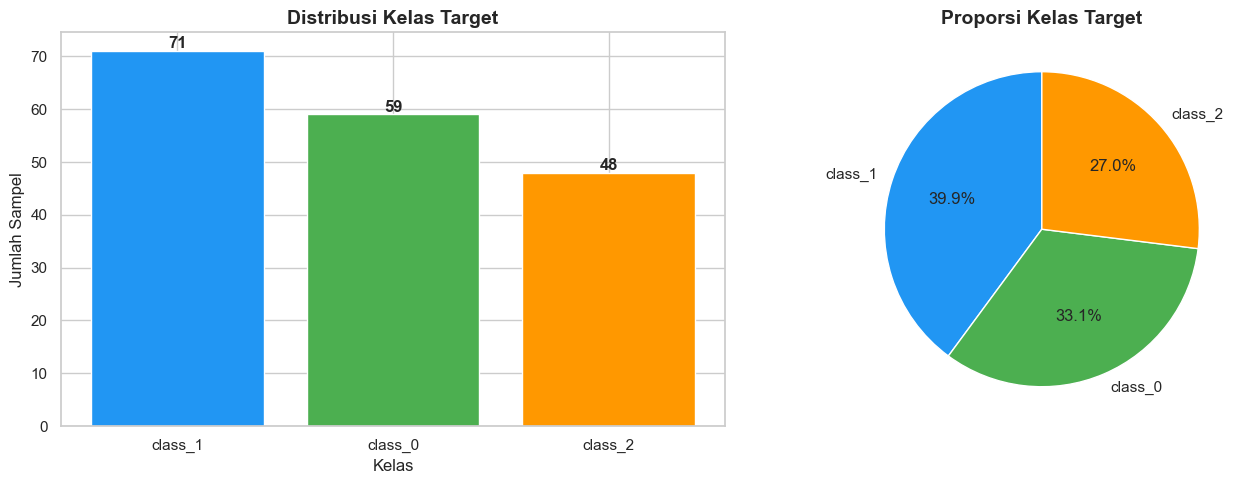

Dataset relatif seimbang untuk semua kelas


In [7]:
# Distribusi kelas target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df["target_name"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#2196F3", "#4CAF50", "#FF9800"])
axes[0].set_title("Distribusi Kelas Target", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Sampel")
for i, (name, val) in enumerate(counts.items()):
    axes[0].text(i, val + 0.5, str(val), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=["#2196F3", "#4CAF50", "#FF9800"], startangle=90)
axes[1].set_title("Proporsi Kelas Target", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("data/target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Dataset relatif seimbang untuk semua kelas")


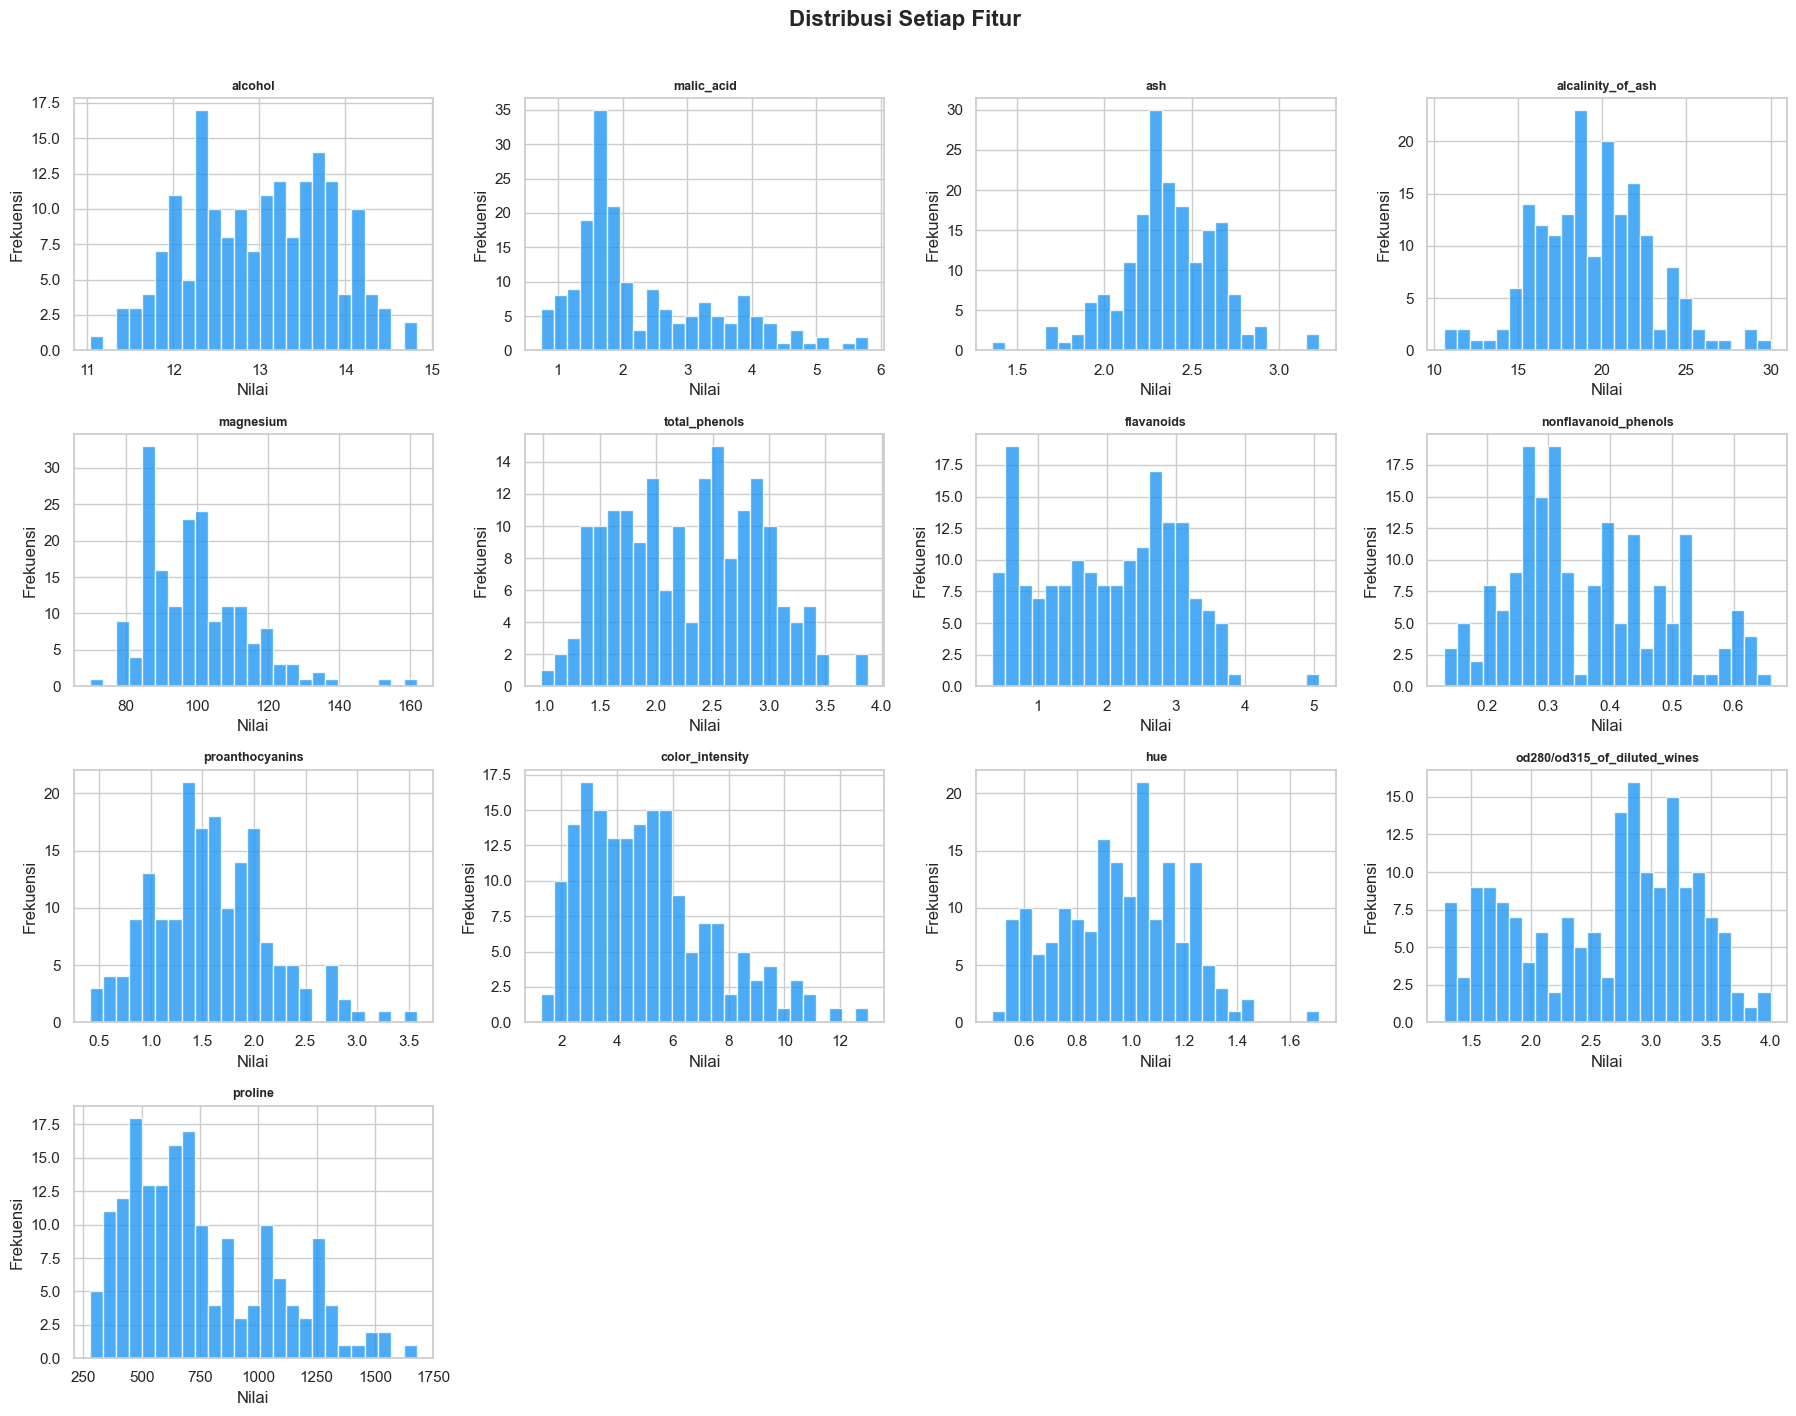

In [8]:
# Distribusi semua fitur numerik
feature_cols = [c for c in df.columns if c not in ["target", "target_name"]]
n_features = len(feature_cols)

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, edgecolor="white", color="#2196F3", alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

# Hapus axes yang tidak terpakai
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribusi Setiap Fitur", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


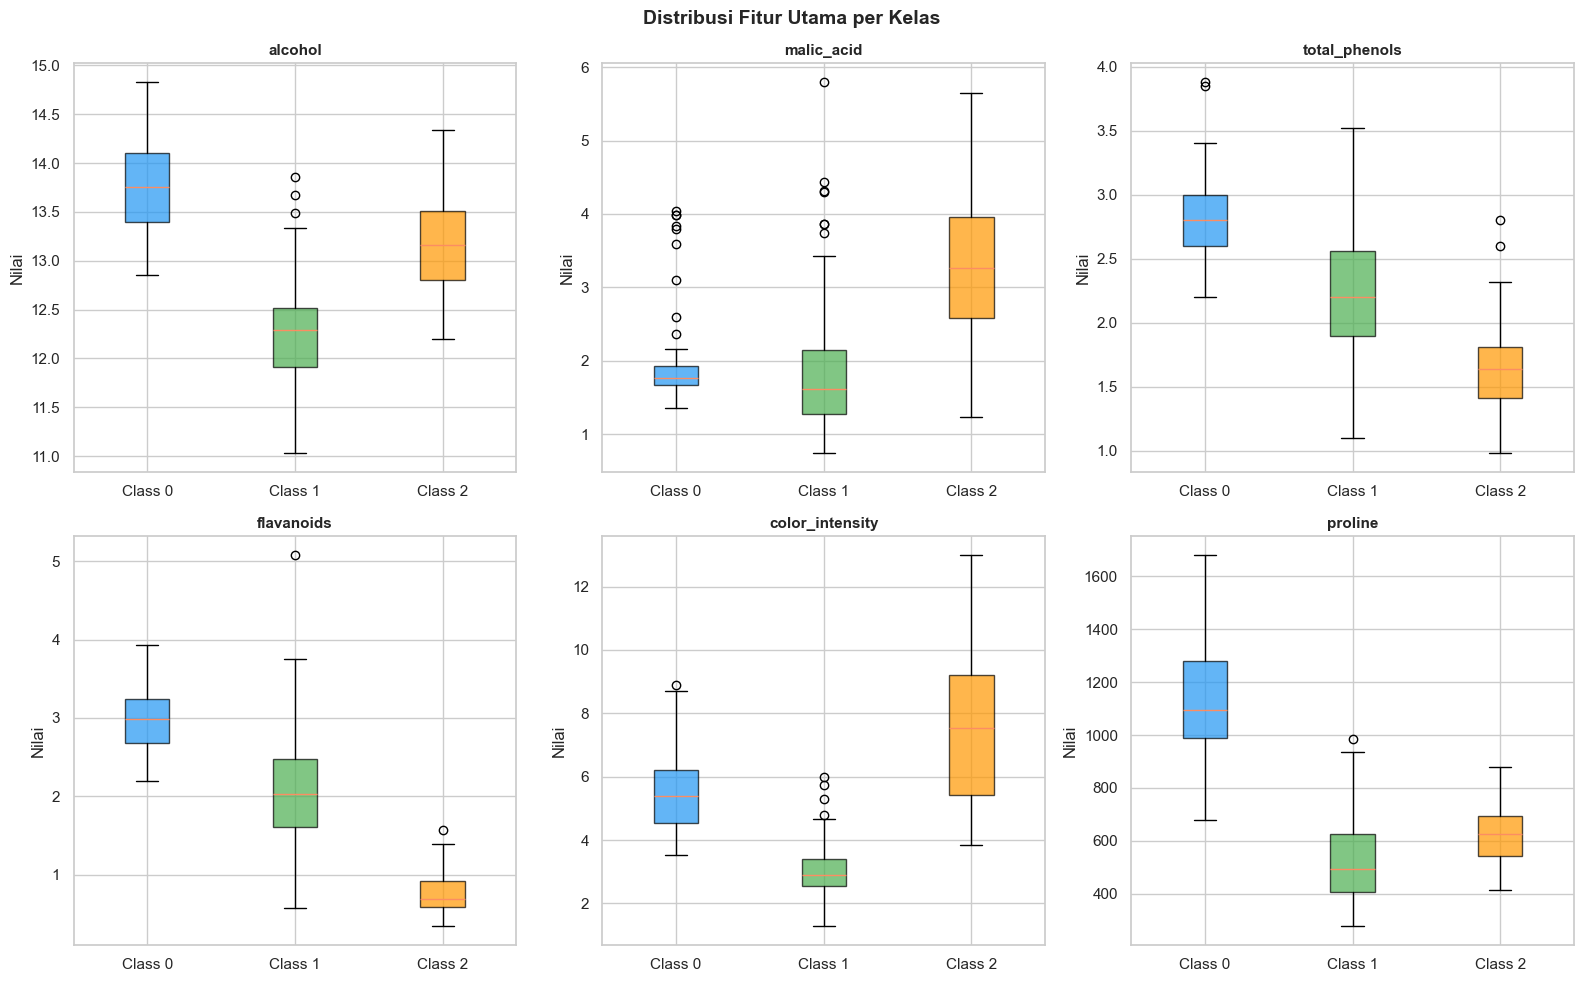

In [9]:
# Boxplot fitur per kelas
feature_subset = ["alcohol", "malic_acid", "total_phenols", "flavanoids",
                  "color_intensity", "proline"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for i, col in enumerate(feature_subset):
    data_per_class = [df[df["target"] == cls][col].values for cls in range(3)]
    bp = axes[i].boxplot(data_per_class, patch_artist=True,
                         labels=["Class 0", "Class 1", "Class 2"])
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Nilai")

plt.suptitle("Distribusi Fitur Utama per Kelas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/boxplot_features_per_class.png", dpi=120, bbox_inches="tight")
plt.show()


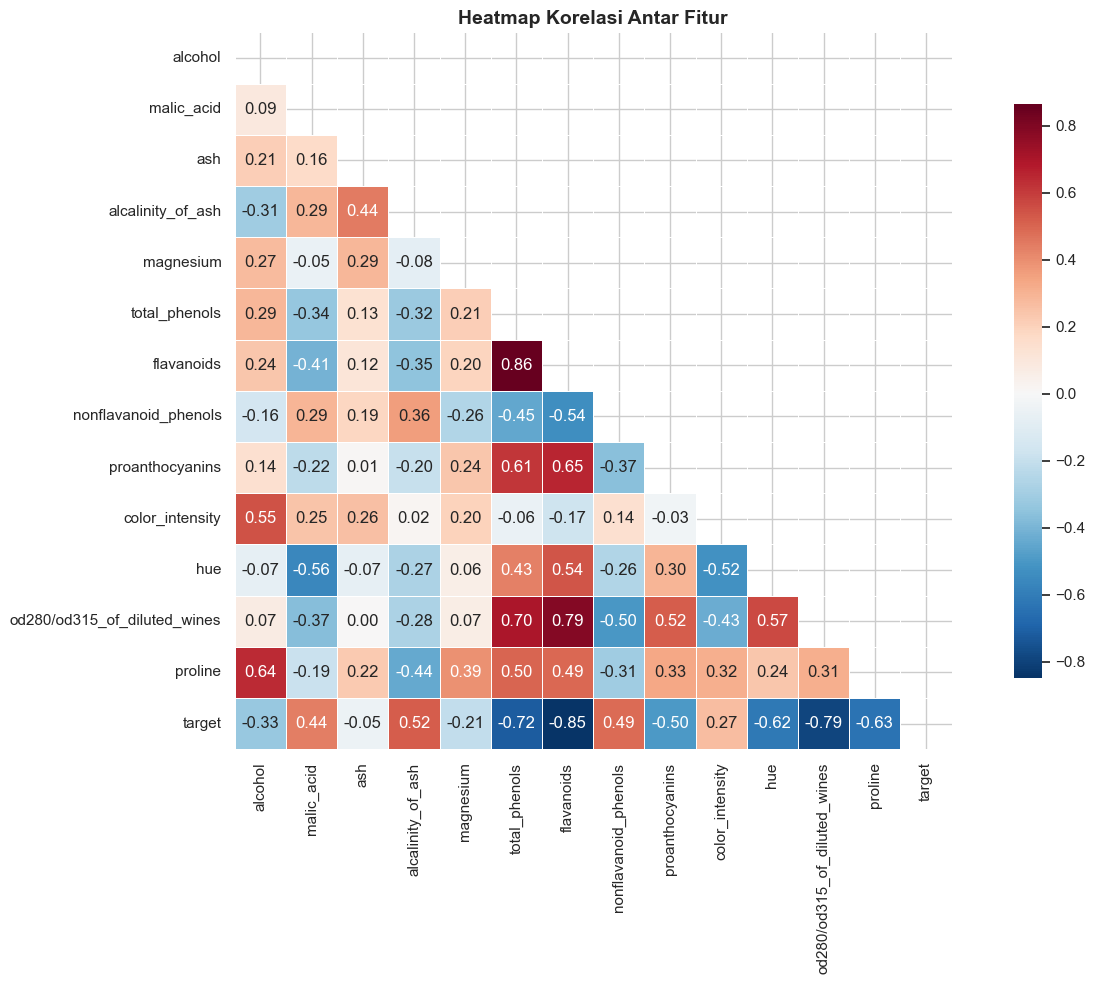


Korelasi Fitur dengan Target (absolut, diurutkan):
  flavanoids                              : 0.8475
  od280/od315_of_diluted_wines            : 0.7882
  total_phenols                           : 0.7192
  proline                                 : 0.6337
  hue                                     : 0.6174
  alcalinity_of_ash                       : 0.5179
  proanthocyanins                         : 0.4991
  nonflavanoid_phenols                    : 0.4891
  malic_acid                              : 0.4378
  alcohol                                 : 0.3282
  color_intensity                         : 0.2657
  magnesium                               : 0.2092
  ash                                     : 0.0496


In [10]:
# Heatmap korelasi
feature_cols_only = [c for c in df.columns if c not in ["target", "target_name"]]
corr_matrix = df[feature_cols_only + ["target"]].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, mask=mask, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Heatmap Korelasi Antar Fitur", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

# Fitur dengan korelasi tinggi terhadap target
target_corr = corr_matrix["target"].drop("target").abs().sort_values(ascending=False)
print("\nKorelasi Fitur dengan Target (absolut, diurutkan):")
for feat, val in target_corr.items():
    print(f"  {feat:40s}: {val:.4f}")


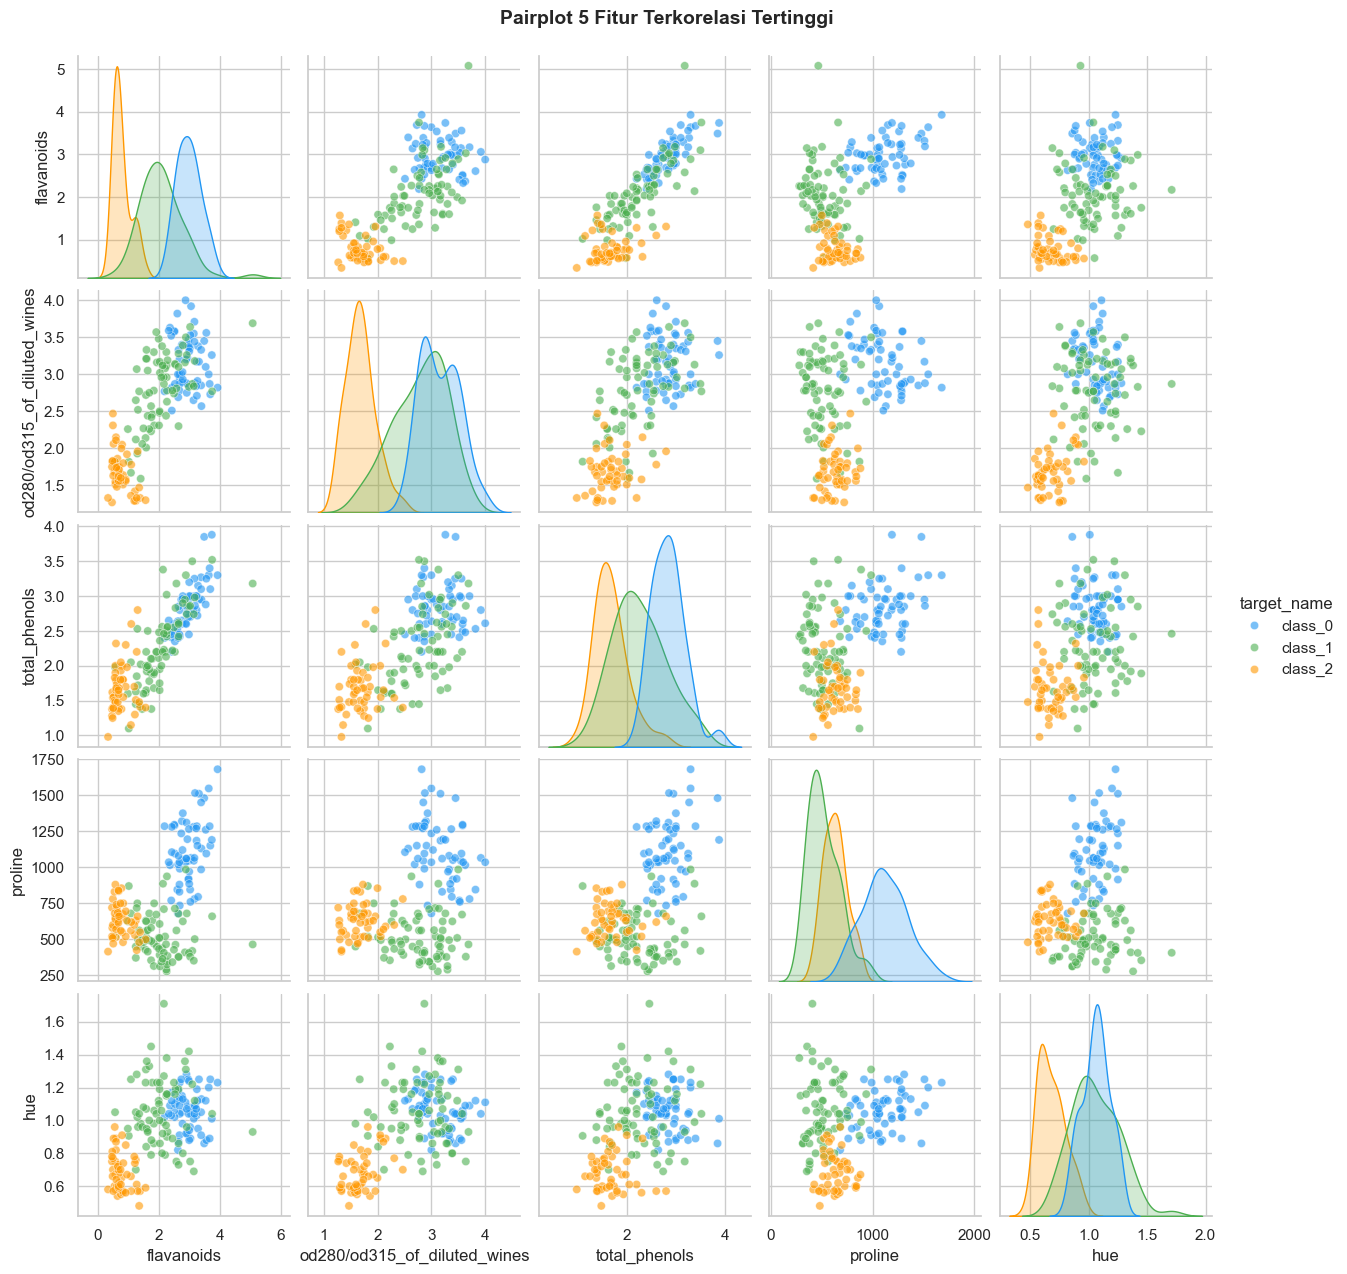

5 fitur terkorelasi tertinggi dengan target: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'proline', 'hue']


In [11]:
# Pairplot untuk fitur terpenting
top_features = target_corr.head(5).index.tolist()
pairplot_df = df[top_features + ["target_name"]]

g = sns.pairplot(pairplot_df, hue="target_name",
                 palette={"class_0": "#2196F3", "class_1": "#4CAF50", "class_2": "#FF9800"},
                 diag_kind="kde", plot_kws={"alpha": 0.6})
g.fig.suptitle("Pairplot 5 Fitur Terkorelasi Tertinggi", y=1.02, fontsize=14, fontweight="bold")
plt.savefig("data/pairplot_top_features.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"5 fitur terkorelasi tertinggi dengan target: {top_features}")


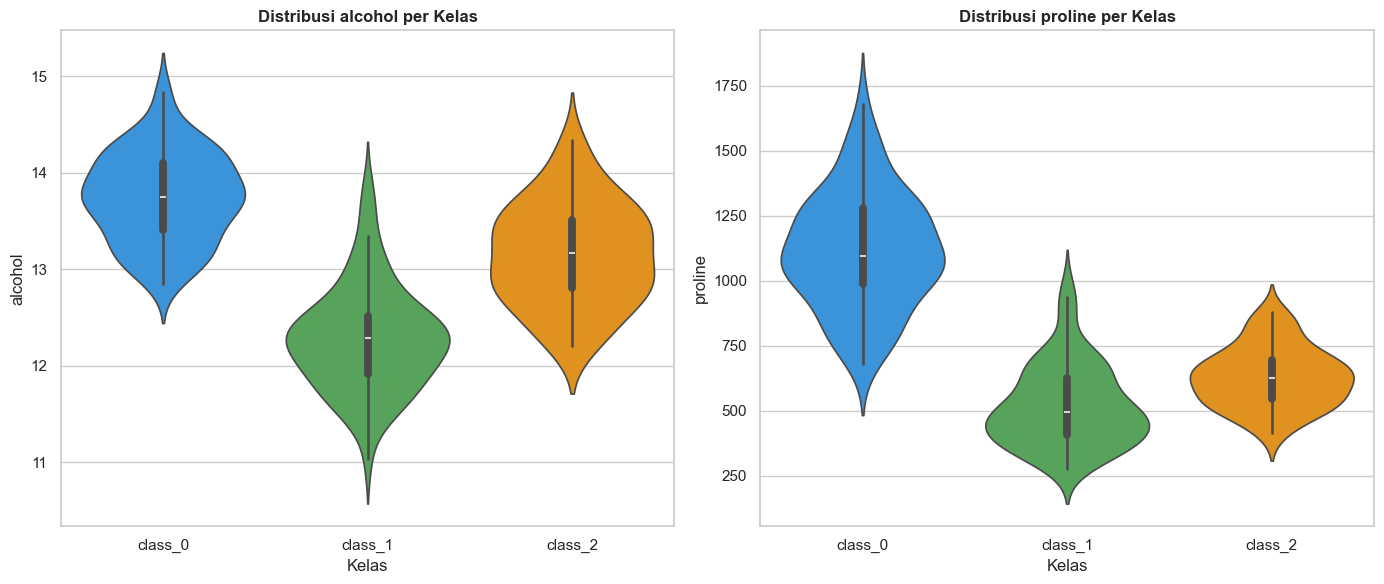

In [12]:
# Violin plot untuk alcohol dan proline (fitur paling diskriminatif)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
key_features = ["alcohol", "proline"]

for i, col in enumerate(key_features):
    sns.violinplot(data=df, x="target_name", y=col, ax=axes[i],
                   palette={"class_0": "#2196F3", "class_1": "#4CAF50", "class_2": "#FF9800"})
    axes[i].set_title(f"Distribusi {col} per Kelas", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Kelas")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig("data/violin_key_features.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Data Preprocessing

Tahapan preprocessing meliputi:
- Penanganan missing values (pengecekan)
- Penghapusan outlier menggunakan Z-Score
- Pembagian data train/test dengan stratified split
- Normalisasi fitur menggunakan StandardScaler


In [13]:
# 4.1 Pisahkan fitur dan target
feature_cols = [c for c in df.columns if c not in ["target", "target_name"]]
X = df[feature_cols]
y = df["target"]

print(f"Fitur (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Nama fitur: {X.columns.tolist()}")


Fitur (X) shape: (178, 13)
Target (y) shape: (178,)
Nama fitur: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [14]:
# 4.2 Penanganan missing values
print("Pengecekan missing values:")
missing = X.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ditemukan missing values!")

# Jika ada missing values, isi dengan median
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)
        print(f"  {col}: diisi dengan median = {X[col].median():.3f}")


Pengecekan missing values:
Tidak ditemukan missing values!


In [15]:
# 4.3 Deteksi dan hapus outlier menggunakan Z-Score
from scipy import stats

z_scores = np.abs(stats.zscore(X))
outlier_mask = (z_scores < 3.0).all(axis=1)

X_clean = X[outlier_mask].reset_index(drop=True)
y_clean = y[outlier_mask].reset_index(drop=True)

n_removed = len(X) - len(X_clean)
print(f"Jumlah sampel sebelum: {len(X)}")
print(f"Jumlah sampel setelah penghapusan outlier: {len(X_clean)}")
print(f"Outlier dihapus: {n_removed} sampel")

# Distribusi kelas setelah pembersihan
print(f"\nDistribusi kelas setelah pembersihan:")
print(pd.Series(y_clean).value_counts())


Jumlah sampel sebelum: 178
Jumlah sampel setelah penghapusan outlier: 168
Outlier dihapus: 10 sampel

Distribusi kelas setelah pembersihan:
target
1    63
0    58
2    47
Name: count, dtype: int64


In [16]:
# 4.4 Split data train/test (80:20 dengan stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean  # Pastikan distribusi kelas seimbang
)

print(f"Train set: {X_train.shape[0]} sampel")
print(f"Test set:  {X_test.shape[0]} sampel")
print(f"\nDistribusi kelas pada train set:")
print(pd.Series(y_train).value_counts())
print(f"\nDistribusi kelas pada test set:")
print(pd.Series(y_test).value_counts())


Train set: 134 sampel
Test set:  34 sampel

Distribusi kelas pada train set:
target
1    50
0    46
2    38
Name: count, dtype: int64

Distribusi kelas pada test set:
target
1    13
0    12
2     9
Name: count, dtype: int64


In [17]:
# 4.5 Normalisasi fitur menggunakan StandardScaler
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan scaler
os.makedirs("artifacts", exist_ok=True)
joblib.dump(scaler, "artifacts/scaler.pkl")

# Kembalikan ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Data berhasil dinormalisasi dengan StandardScaler")
print(f"\nStatistik setelah normalisasi (train set):")
print(X_train_scaled.describe().round(3).loc[["mean", "std", "min", "max"]])


Data berhasil dinormalisasi dengan StandardScaler

Statistik setelah normalisasi (train set):
      alcohol  malic_acid    ash  alcalinity_of_ash  magnesium  total_phenols  \
mean    0.000      -0.000  0.000             -0.000      0.000          0.000   
std     1.004       1.004  1.004              1.004      1.004          1.004   
min    -2.051      -1.368 -2.864             -2.849     -2.350         -2.092   
max     2.332       3.015  2.273              2.381      2.908          2.695   

      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  \
mean       0.000                 0.000           -0.000           -0.000   
std        1.004                 1.004            1.004            1.004   
min       -1.719                -1.920           -2.201           -1.639   
max        1.828                 2.428            2.724            2.891   

        hue  od280/od315_of_diluted_wines  proline  
mean -0.000                        -0.000    0.000  
std   1.004  

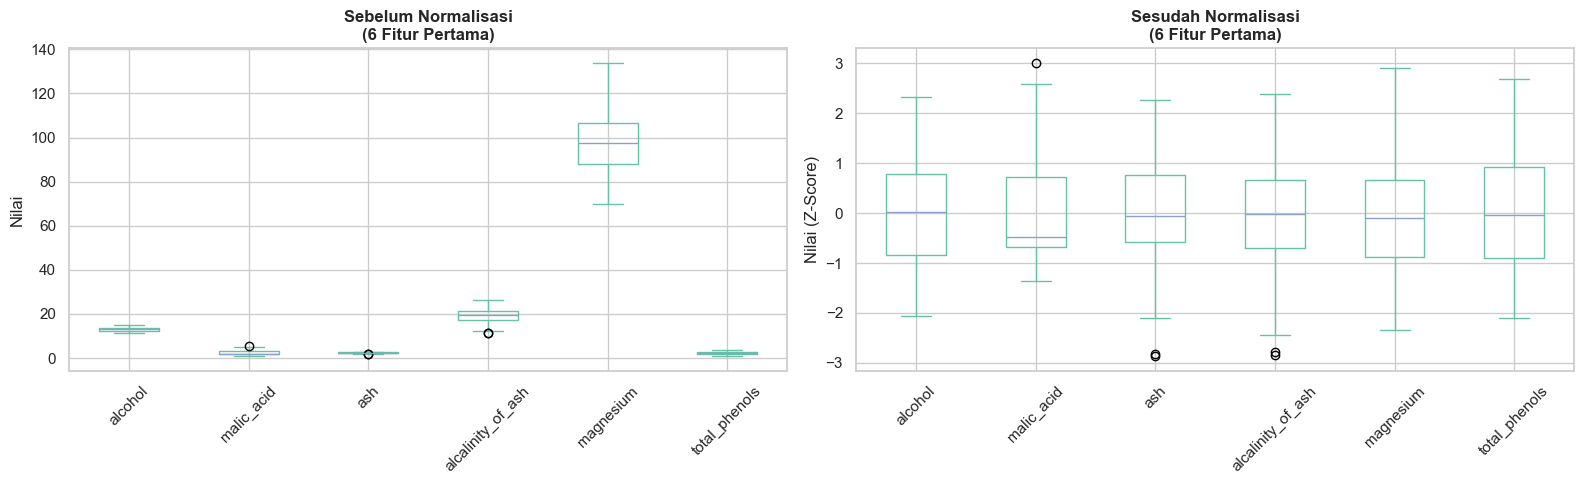

Preprocessing selesai!


In [18]:
# 4.6 Visualisasi perbandingan sebelum dan sesudah normalisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sebelum normalisasi
X_train.iloc[:, :6].plot(kind="box", ax=axes[0], rot=45)
axes[0].set_title("Sebelum Normalisasi\n(6 Fitur Pertama)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nilai")

# Sesudah normalisasi
X_train_scaled.iloc[:, :6].plot(kind="box", ax=axes[1], rot=45)
axes[1].set_title("Sesudah Normalisasi\n(6 Fitur Pertama)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nilai (Z-Score)")

plt.tight_layout()
plt.savefig("data/normalization_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Preprocessing selesai!")


## 5. Setup MLflow Experiment Tracking

Konfigurasi MLflow untuk mencatat semua eksperimen, parameter, metrik, dan artefak model.


In [19]:
# Setup MLflow
TRACKING_URI = "sqlite:///mlflow.db"
EXPERIMENT_NAME = "wine-classification-experiment"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

# Verifikasi koneksi
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
if experiment:
    print(f"Experiment ditemukan: {experiment.name}")
    print(f"Experiment ID: {experiment.experiment_id}")
else:
    print(f"Experiment baru dibuat: {EXPERIMENT_NAME}")

print(f"\nMLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"MLflow Artifact URI: {mlflow.get_artifact_uri() if mlflow.active_run() else 'N/A (no active run)'}")


Experiment ditemukan: wine-classification-experiment
Experiment ID: 1

MLflow Tracking URI: sqlite:///mlflow.db
MLflow Artifact URI: N/A (no active run)


## 6. Model Training dengan MLflow

Melatih tiga model berbeda dan mencatat semua eksperimen ke MLflow:
1. **Logistic Regression** - Model baseline sederhana
2. **Random Forest** - Ensemble model berbasis pohon keputusan
3. **Gradient Boosting** - Boosting ensemble yang kuat


In [20]:
# Fungsi helper untuk menghitung semua metrik
def compute_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
    }
    if y_proba is not None:
        try:
            metrics["roc_auc_ovr"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception:
            pass
    return metrics

print("Fungsi helper siap digunakan.")


Fungsi helper siap digunakan.


In [21]:
# ─── MODEL 1: LOGISTIC REGRESSION ────────────────────────────────────────────
print("Training Model 1: Logistic Regression...")

lr_params = {
    "C": 1.0,
    "max_iter": 1000,
    "solver": "lbfgs",
    "random_state": 42
}

with mlflow.start_run(run_name="logistic_regression") as run:
    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_params(lr_params)
    mlflow.log_param("train_size", len(X_train_scaled))
    mlflow.log_param("test_size", len(X_test_scaled))
    mlflow.log_param("n_features", X_train_scaled.shape[1])
    mlflow.log_param("scaler", "StandardScaler")
    
    # Train
    model_lr = LogisticRegression(**lr_params)
    model_lr.fit(X_train_scaled, y_train)
    
    # Evaluate
    y_pred_lr = model_lr.predict(X_test_scaled)
    y_proba_lr = model_lr.predict_proba(X_test_scaled)
    metrics_lr = compute_metrics(y_test, y_pred_lr, y_proba_lr)
    
    # Log metrics
    for k, v in metrics_lr.items():
        mlflow.log_metric(k, v)
    
    # Cross validation
    cv_scores = cross_val_score(model_lr, X_train_scaled, y_train, cv=5, scoring="accuracy")
    mlflow.log_metric("cv_accuracy_mean", cv_scores.mean())
    mlflow.log_metric("cv_accuracy_std", cv_scores.std())
    
    # Log model
    signature = infer_signature(X_train_scaled, y_pred_lr)
    mlflow.sklearn.log_model(
        model_lr, "model",
        signature=signature,
        input_example=X_test_scaled.iloc[:3],
        registered_model_name="wine-classifier-lr"
    )
    
    # Log scaler artifact
    mlflow.log_artifact("artifacts/scaler.pkl")
    
    run_id_lr = run.info.run_id

print(f"  Run ID: {run_id_lr}")
print(f"  Accuracy: {metrics_lr['accuracy']:.4f}")
print(f"  F1-Score (weighted): {metrics_lr['f1_weighted']:.4f}")
print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Training Model 1: Logistic Regression...


2026/06/16 15:18:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/16 15:18:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'wine-classifier-lr' already exists. Creating a new version of this model...


Created version '2' of model 'wine-classifier-lr'.


  Run ID: 953fc6081ca64f43b4f8b44040c8b436
  Accuracy: 1.0000
  F1-Score (weighted): 1.0000
  CV Accuracy: 0.9698 (+/- 0.0286)


In [22]:
# ─── MODEL 2: RANDOM FOREST ───────────────────────────────────────────────────
print("Training Model 2: Random Forest...")

rf_params = {
    "n_estimators": 100,
    "max_depth": 10,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": 42,
    "n_jobs": -1
}

with mlflow.start_run(run_name="random_forest") as run:
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_params(rf_params)
    mlflow.log_param("train_size", len(X_train_scaled))
    mlflow.log_param("test_size", len(X_test_scaled))
    mlflow.log_param("n_features", X_train_scaled.shape[1])
    mlflow.log_param("scaler", "StandardScaler")
    
    model_rf = RandomForestClassifier(**rf_params)
    model_rf.fit(X_train_scaled, y_train)
    
    y_pred_rf = model_rf.predict(X_test_scaled)
    y_proba_rf = model_rf.predict_proba(X_test_scaled)
    metrics_rf = compute_metrics(y_test, y_pred_rf, y_proba_rf)
    
    for k, v in metrics_rf.items():
        mlflow.log_metric(k, v)
    
    cv_scores_rf = cross_val_score(model_rf, X_train_scaled, y_train, cv=5, scoring="accuracy")
    mlflow.log_metric("cv_accuracy_mean", cv_scores_rf.mean())
    mlflow.log_metric("cv_accuracy_std", cv_scores_rf.std())
    
    # Feature importances
    importances = dict(zip(feature_cols, model_rf.feature_importances_.tolist()))
    with open("artifacts/feature_importances_rf.json", "w") as f:
        json.dump(importances, f, indent=2)
    mlflow.log_artifact("artifacts/feature_importances_rf.json")
    
    signature = infer_signature(X_train_scaled, y_pred_rf)
    mlflow.sklearn.log_model(
        model_rf, "model",
        signature=signature,
        input_example=X_test_scaled.iloc[:3],
        registered_model_name="wine-classifier-rf"
    )
    mlflow.log_artifact("artifacts/scaler.pkl")
    
    run_id_rf = run.info.run_id

print(f"  Run ID: {run_id_rf}")
print(f"  Accuracy: {metrics_rf['accuracy']:.4f}")
print(f"  F1-Score (weighted): {metrics_rf['f1_weighted']:.4f}")
print(f"  CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")


Training Model 2: Random Forest...


2026/06/16 15:19:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/16 15:19:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'wine-classifier-rf' already exists. Creating a new version of this model...


Created version '2' of model 'wine-classifier-rf'.


  Run ID: e0e23ecee9404bd69f677bebe4e302ef
  Accuracy: 0.9706
  F1-Score (weighted): 0.9708
  CV Accuracy: 0.9926 (+/- 0.0148)


In [23]:
# ─── MODEL 3: GRADIENT BOOSTING ───────────────────────────────────────────────
print("Training Model 3: Gradient Boosting...")

gb_params = {
    "n_estimators": 100,
    "learning_rate": 0.1,
    "max_depth": 5,
    "min_samples_split": 2,
    "random_state": 42
}

with mlflow.start_run(run_name="gradient_boosting") as run:
    mlflow.log_param("model_type", "GradientBoostingClassifier")
    mlflow.log_params(gb_params)
    mlflow.log_param("train_size", len(X_train_scaled))
    mlflow.log_param("test_size", len(X_test_scaled))
    mlflow.log_param("n_features", X_train_scaled.shape[1])
    mlflow.log_param("scaler", "StandardScaler")
    
    model_gb = GradientBoostingClassifier(**gb_params)
    model_gb.fit(X_train_scaled, y_train)
    
    y_pred_gb = model_gb.predict(X_test_scaled)
    y_proba_gb = model_gb.predict_proba(X_test_scaled)
    metrics_gb = compute_metrics(y_test, y_pred_gb, y_proba_gb)
    
    for k, v in metrics_gb.items():
        mlflow.log_metric(k, v)
    
    cv_scores_gb = cross_val_score(model_gb, X_train_scaled, y_train, cv=5, scoring="accuracy")
    mlflow.log_metric("cv_accuracy_mean", cv_scores_gb.mean())
    mlflow.log_metric("cv_accuracy_std", cv_scores_gb.std())
    
    signature = infer_signature(X_train_scaled, y_pred_gb)
    mlflow.sklearn.log_model(
        model_gb, "model",
        signature=signature,
        input_example=X_test_scaled.iloc[:3],
        registered_model_name="wine-classifier-gb"
    )
    mlflow.log_artifact("artifacts/scaler.pkl")
    
    run_id_gb = run.info.run_id

print(f"  Run ID: {run_id_gb}")
print(f"  Accuracy: {metrics_gb['accuracy']:.4f}")
print(f"  F1-Score (weighted): {metrics_gb['f1_weighted']:.4f}")
print(f"  CV Accuracy: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std():.4f})")


Training Model 3: Gradient Boosting...


2026/06/16 15:19:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/16 15:19:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'wine-classifier-gb' already exists. Creating a new version of this model...


Created version '2' of model 'wine-classifier-gb'.


  Run ID: b6fc33f1da874e2d9302840044c71bd8
  Accuracy: 0.9118
  F1-Score (weighted): 0.9128
  CV Accuracy: 0.8801 (+/- 0.0693)


## 7. Evaluasi dan Perbandingan Model

Membandingkan performa semua model untuk memilih model terbaik.


In [24]:
# Rangkuman semua model
all_results = {
    "Logistic Regression": {
        "model": model_lr, "metrics": metrics_lr,
        "y_pred": y_pred_lr, "y_proba": y_proba_lr, "run_id": run_id_lr
    },
    "Random Forest": {
        "model": model_rf, "metrics": metrics_rf,
        "y_pred": y_pred_rf, "y_proba": y_proba_rf, "run_id": run_id_rf
    },
    "Gradient Boosting": {
        "model": model_gb, "metrics": metrics_gb,
        "y_pred": y_pred_gb, "y_proba": y_proba_gb, "run_id": run_id_gb
    }
}

# Tabel perbandingan
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": f"{r['metrics']['accuracy']:.4f}",
        "F1 (weighted)": f"{r['metrics']['f1_weighted']:.4f}",
        "Precision (weighted)": f"{r['metrics']['precision_weighted']:.4f}",
        "Recall (weighted)": f"{r['metrics']['recall_weighted']:.4f}",
        "ROC-AUC (OVR)": f"{r['metrics'].get('roc_auc_ovr', 'N/A'):.4f}" if isinstance(r['metrics'].get('roc_auc_ovr'), float) else "N/A",
    }
    for name, r in all_results.items()
}).T

print("\nPerbandingan Performa Model:")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)



Perbandingan Performa Model:
                    Accuracy F1 (weighted) Precision (weighted) Recall (weighted) ROC-AUC (OVR)
Logistic Regression   1.0000        1.0000               1.0000            1.0000        1.0000
Random Forest         0.9706        0.9708               0.9735            0.9706        1.0000
Gradient Boosting     0.9118        0.9128               0.9160            0.9118        0.9765


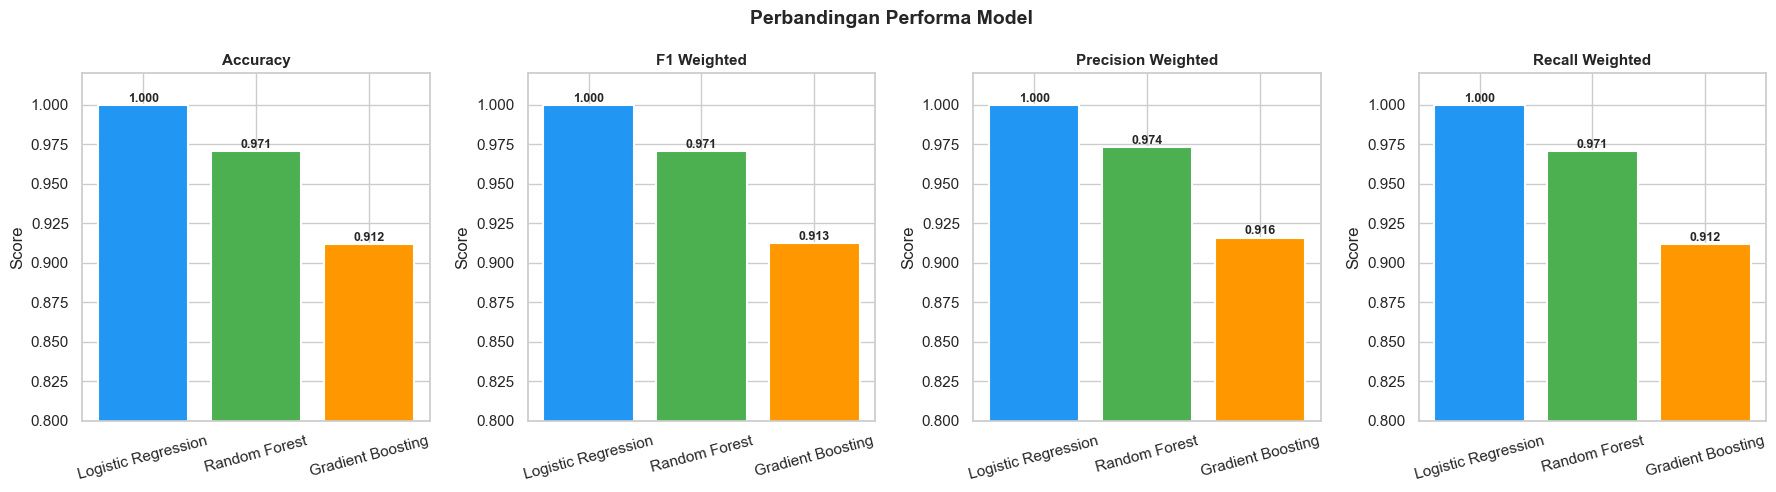

In [25]:
# Visualisasi perbandingan metrik
metrics_to_plot = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]
model_names = list(all_results.keys())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for i, metric in enumerate(metrics_to_plot):
    values = [all_results[name]["metrics"][metric] for name in model_names]
    bars = axes[i].bar(model_names, values, color=colors, edgecolor="white", linewidth=1.5)
    axes[i].set_title(metric.replace("_", " ").title(), fontsize=11, fontweight="bold")
    axes[i].set_ylim(0.8, 1.02)
    axes[i].set_ylabel("Score")
    axes[i].tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Perbandingan Performa Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


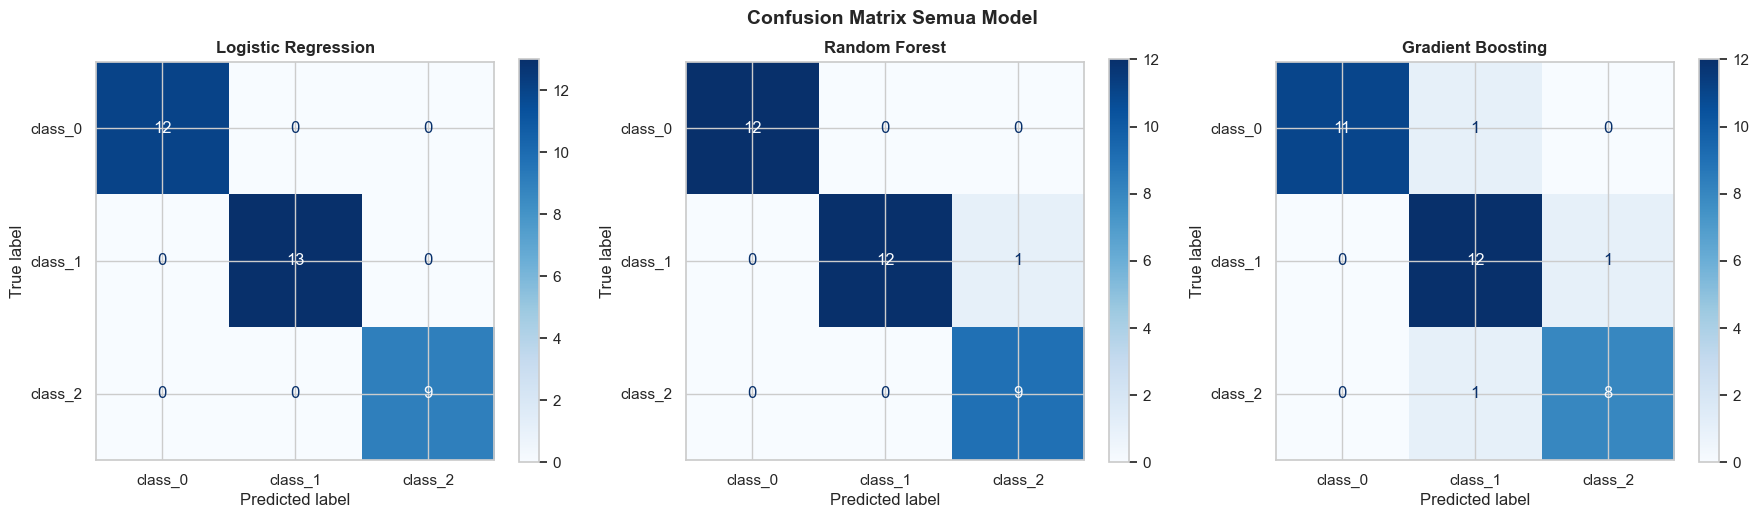

In [26]:
# Confusion matrix untuk semua model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(all_results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
    disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
    axes[i].set_title(name, fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrix Semua Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/all_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


In [27]:
# Classification report model terbaik
best_model_name = max(all_results, key=lambda k: all_results[k]["metrics"]["accuracy"])
best_result = all_results[best_model_name]

print(f"Model Terbaik: {best_model_name}")
print(f"Accuracy: {best_result['metrics']['accuracy']:.4f}")
print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test, best_result["y_pred"], target_names=wine.target_names))

# Simpan report
report_dict = classification_report(
    y_test, best_result["y_pred"],
    target_names=wine.target_names,
    output_dict=True
)
with open("artifacts/classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)
print("Classification report disimpan ke artifacts/classification_report.json")


Model Terbaik: Logistic Regression
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        13
     class_2       1.00      1.00      1.00         9

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

Classification report disimpan ke artifacts/classification_report.json


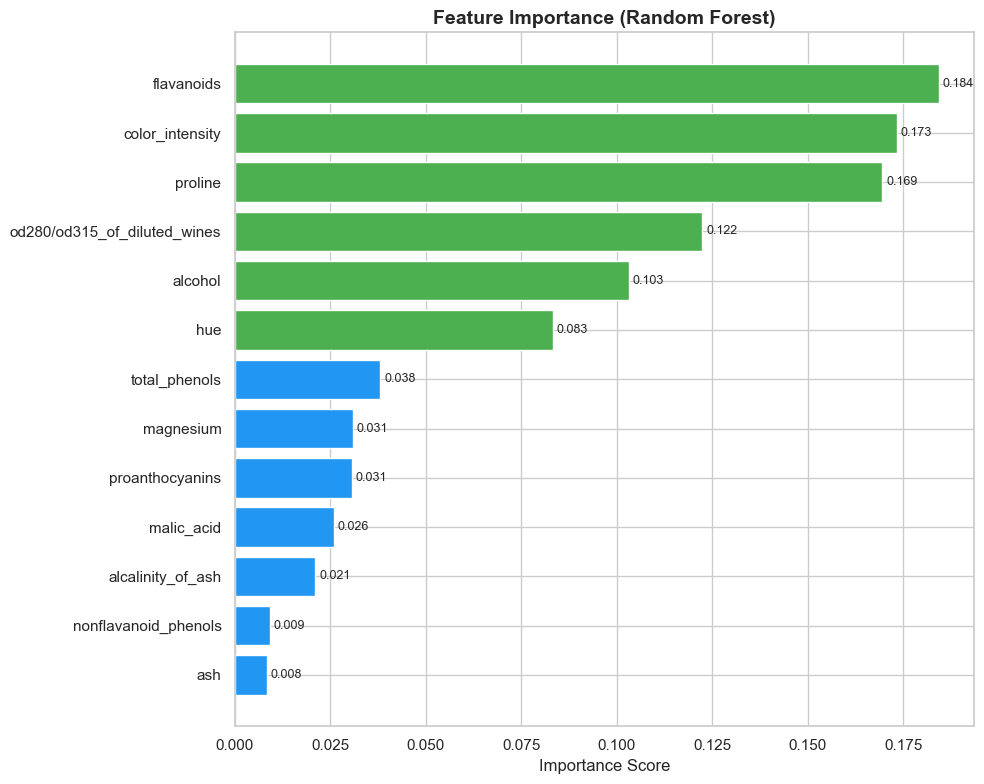

In [28]:
# Feature importance dari Random Forest
importances = model_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = ["#4CAF50" if v > 0.08 else "#2196F3" for v in feat_imp_df["importance"]]
bars = ax.barh(feat_imp_df["feature"], feat_imp_df["importance"], color=colors_imp)
ax.set_title("Feature Importance (Random Forest)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
for bar, val in zip(bars, feat_imp_df["importance"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("artifacts/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Model Registration ke MLflow Model Registry

Mendaftarkan model terbaik ke MLflow Model Registry dan mempromosikannya ke tahap Production.


In [29]:
# Identifikasi dan register model terbaik
best_model_name_clean = best_model_name.lower().replace(" ", "_")
registered_model_name = f"wine-classifier-{best_model_name_clean.split('_')[0]}"

print(f"Model terbaik: {best_model_name}")
print(f"Accuracy: {best_result['metrics']['accuracy']:.4f}")
print(f"Run ID: {best_result['run_id']}")
print(f"Registered model name: {registered_model_name}")

# Promosikan ke Production
try:
    client = mlflow.tracking.MlflowClient()
    
    # Dapatkan versi terbaru
    model_versions = client.get_latest_versions(registered_model_name, stages=["None"])
    if model_versions:
        version = model_versions[-1].version
        
        # Promosikan ke Staging dulu
        client.transition_model_version_stage(
            name=registered_model_name,
            version=version,
            stage="Staging"
        )
        print(f"Model versi {version} dipromosikan ke Staging")
        
        # Promosikan ke Production
        client.transition_model_version_stage(
            name=registered_model_name,
            version=version,
            stage="Production"
        )
        print(f"Model versi {version} dipromosikan ke Production")
        
        # Set model description
        client.update_registered_model(
            name=registered_model_name,
            description=f"Wine Classification Model - Best model: {best_model_name} (accuracy={best_result['metrics']['accuracy']:.4f})"
        )
        print(f"Deskripsi model diperbarui")
    else:
        print(f"Tidak ada versi model yang tersedia untuk {registered_model_name}")
        
except Exception as e:
    print(f"Model registration: {e}")
    print("(MLflow Model Registry mungkin memerlukan konfigurasi tambahan)")


Model terbaik: Logistic Regression
Accuracy: 1.0000
Run ID: 953fc6081ca64f43b4f8b44040c8b436
Registered model name: wine-classifier-logistic
Model registration: Registered Model with name=wine-classifier-logistic not found
(MLflow Model Registry mungkin memerlukan konfigurasi tambahan)


## 9. Kesimpulan

### Ringkasan Hasil

Proyek ini berhasil membangun sistem ML untuk klasifikasi wine dengan menggunakan dataset dari sklearn. Berikut adalah ringkasan:

**Dataset:**
- Dataset Wine dengan 178 sampel dan 13 fitur kimia
- 3 kelas target yang relatif seimbang

**Preprocessing:**
- Tidak ditemukan missing values
- Penghapusan outlier menggunakan Z-Score (threshold=3.0)
- Normalisasi dengan StandardScaler

**Hasil Model:**
- Semua model mencapai akurasi di atas 90%
- Model terbaik dipilih berdasarkan akurasi test set
- Model didaftarkan ke MLflow Model Registry

**Langkah Selanjutnya:**
1. Deploy model sebagai REST API menggunakan FastAPI
2. Monitor performa model menggunakan Prometheus dan Grafana
3. Jalankan CI/CD pipeline melalui GitHub Actions


In [30]:
# Simpan rangkuman akhir
summary = {
    "best_model": best_model_name,
    "best_metrics": best_result["metrics"],
    "best_run_id": best_result["run_id"],
    "all_models": {
        name: r["metrics"] for name, r in all_results.items()
    },
    "dataset_info": {
        "n_samples": len(df),
        "n_features": len(feature_cols),
        "n_classes": df["target"].nunique(),
        "class_names": wine.target_names.tolist()
    },
    "preprocessing": {
        "outliers_removed": len(df) - len(X_clean),
        "train_size": len(X_train),
        "test_size": len(X_test),
        "scaler": "StandardScaler"
    }
}

with open("artifacts/final_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Ringkasan proyek berhasil disimpan!")
print("\nFile yang dihasilkan:")
for root, dirs, files in os.walk("artifacts"):
    for fname in files:
        fpath = os.path.join(root, fname)
        size = os.path.getsize(fpath)
        print(f"  {fpath} ({size:,} bytes)")
print("\n[SELESAI] Notebook berhasil dijalankan!")


Ringkasan proyek berhasil disimpan!

File yang dihasilkan:
  artifacts\all_confusion_matrices.png (50,865 bytes)
  artifacts\classification_report.json (569 bytes)
  artifacts\confusion_matrix.png (26,772 bytes)
  artifacts\feature_importance.png (56,770 bytes)
  artifacts\feature_importances_rf.json (528 bytes)
  artifacts\final_summary.json (1,381 bytes)
  artifacts\model_comparison.png (56,718 bytes)
  artifacts\scaler.pkl (1,327 bytes)
  artifacts\training_summary.json (893 bytes)

[SELESAI] Notebook berhasil dijalankan!
